In [1]:
!git clone https://github.com/shankarpandala/lazypredict.git
#* git clone 是 Git 的一個命令，用來將遠程儲存庫的內容複製到本地目錄中

Cloning into 'lazypredict'...
remote: Enumerating objects: 983, done.
remote: Counting objects: 100% (327/327), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 983 (delta 241), reused 264 (delta 220), pack-reused 656 (from 1)
Receiving objects: 100% (983/983), 192.73 KiB | 7.41 MiB/s, done.
Resolving deltas: 100% (536/536), done.


In [2]:
!pip install -U ydata-profiling
!pip install dask-expr

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.2/356.2 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 80.5 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=fa258095baca2822c96178337d7c96bc166c404d1c9bf3e09a5415528130542d
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.3 MB/s eta 0:00:00
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 2.2.1
    Uninstalling cloudpickle

In [3]:
"""
Supervised Models
"""
# Author: Shankar Rao Pandala <shankar.pandala@live.com>

import numpy as np
import pandas as pd
from tqdm import tqdm
import datetime
import time
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils import all_estimators
from sklearn.base import RegressorMixin
from sklearn.base import ClassifierMixin
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    f1_score,
    r2_score,
    mean_squared_error,
)
import warnings
import xgboost

# import catboost
import lightgbm

warnings.filterwarnings("ignore")
pd.set_option("display.precision", 2)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

removed_classifiers = [
    "ClassifierChain",
#    "ComplementNB",
#    "GradientBoostingClassifier",
#    "GaussianProcessClassifier",
#    "HistGradientBoostingClassifier",
#    "MLPClassifier",
#    "LogisticRegressionCV",
    "MultiOutputClassifier",
    "MultinomialNB",
    "OneVsOneClassifier",
    "OneVsRestClassifier",
    "OutputCodeClassifier",
#    "RadiusNeighborsClassifier",
    "VotingClassifier",
]

removed_regressors = [
#    "TheilSenRegressor",
#    "ARDRegression",
    "CCA",
#    "IsotonicRegression",
    "StackingRegressor",
    "MultiOutputRegressor",
    "MultiTaskElasticNet",
    "MultiTaskElasticNetCV",
    "MultiTaskLasso",
    "MultiTaskLassoCV",
    "PLSCanonical",
    "PLSRegression",
#    "RadiusNeighborsRegressor",
    "RegressorChain",
    "VotingRegressor",
]

CLASSIFIERS = [
    est
    for est in all_estimators()
    if (issubclass(est[1], ClassifierMixin) and (est[0] not in removed_classifiers))
]

REGRESSORS = [
    est
    for est in all_estimators()
    if (issubclass(est[1], RegressorMixin) and (est[0] not in removed_regressors))
]

REGRESSORS.append(("XGBRegressor", xgboost.XGBRegressor))
REGRESSORS.append(("LGBMRegressor", lightgbm.LGBMRegressor))
# REGRESSORS.append(('CatBoostRegressor',catboost.CatBoostRegressor))

CLASSIFIERS.append(("XGBClassifier", xgboost.XGBClassifier))
CLASSIFIERS.append(("LGBMClassifier", lightgbm.LGBMClassifier))
# CLASSIFIERS.append(('CatBoostClassifier',catboost.CatBoostClassifier))

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="mean")), ("scaler", StandardScaler())]
)

categorical_transformer_low = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("encoding", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

categorical_transformer_high = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        # 'OrdianlEncoder' Raise a ValueError when encounters an unknown value. Check https://github.com/scikit-learn/scikit-learn/pull/13423
        ("encoding", OrdinalEncoder()),
    ]
)


# Helper function


def get_card_split(df, cols, n=11):
    """
    Splits categorical columns into 2 lists based on cardinality (i.e # of unique values)
    Parameters
    ----------
    df : Pandas DataFrame
        DataFrame from which the cardinality of the columns is calculated.
    cols : list-like
        Categorical columns to list
    n : int, optional (default=11)
        The value of 'n' will be used to split columns.
    Returns
    -------
    card_low : list-like
        Columns with cardinality < n
    card_high : list-like
        Columns with cardinality >= n
    """
    cond = df[cols].nunique() > n
    card_high = cols[cond]
    card_low = cols[~cond]
    return card_low, card_high


# Helper class for performing classification


class LazyClassifier:
    """
    This module helps in fitting to all the classification algorithms that are available in Scikit-learn
    Parameters
    ----------
    verbose : int, optional (default=0)
        For the liblinear and lbfgs solvers set verbose to any positive
        number for verbosity.
    ignore_warnings : bool, optional (default=True)
        When set to True, the warning related to algorigms that are not able to run are ignored.
    custom_metric : function, optional (default=None)
        When function is provided, models are evaluated based on the custom evaluation metric provided.
    prediction : bool, optional (default=False)
        When set to True, the predictions of all the models models are returned as dataframe.
    classifiers : list, optional (default="all")
        When function is provided, trains the chosen classifier(s).

    Examples
    --------
    >>> from lazypredict.Supervised import LazyClassifier
    >>> from sklearn.datasets import load_breast_cancer
    >>> from sklearn.model_selection import train_test_split
    >>> data = load_breast_cancer()
    >>> X = data.data
    >>> y= data.target
    >>> X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=.5,random_state =123)
    >>> clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
    >>> models,predictions = clf.fit(X_train, X_test, y_train, y_test)
    >>> model_dictionary = clf.provide_models(X_train,X_test,y_train,y_test)
    >>> models
    | Model                          |   Accuracy |   Balanced Accuracy |   ROC AUC |   F1 Score |   Time Taken |
    |:-------------------------------|-----------:|--------------------:|----------:|-----------:|-------------:|
    | LinearSVC                      |   0.989474 |            0.987544 |  0.987544 |   0.989462 |    0.0150008 |
    | SGDClassifier                  |   0.989474 |            0.987544 |  0.987544 |   0.989462 |    0.0109992 |
    | MLPClassifier                  |   0.985965 |            0.986904 |  0.986904 |   0.985994 |    0.426     |
    | Perceptron                     |   0.985965 |            0.984797 |  0.984797 |   0.985965 |    0.0120046 |
    | LogisticRegression             |   0.985965 |            0.98269  |  0.98269  |   0.985934 |    0.0200036 |
    | LogisticRegressionCV           |   0.985965 |            0.98269  |  0.98269  |   0.985934 |    0.262997  |
    | SVC                            |   0.982456 |            0.979942 |  0.979942 |   0.982437 |    0.0140011 |
    | CalibratedClassifierCV         |   0.982456 |            0.975728 |  0.975728 |   0.982357 |    0.0350015 |
    | PassiveAggressiveClassifier    |   0.975439 |            0.974448 |  0.974448 |   0.975464 |    0.0130005 |
    | LabelPropagation               |   0.975439 |            0.974448 |  0.974448 |   0.975464 |    0.0429988 |
    | LabelSpreading                 |   0.975439 |            0.974448 |  0.974448 |   0.975464 |    0.0310006 |
    | RandomForestClassifier         |   0.97193  |            0.969594 |  0.969594 |   0.97193  |    0.033     |
    | GradientBoostingClassifier     |   0.97193  |            0.967486 |  0.967486 |   0.971869 |    0.166998  |
    | QuadraticDiscriminantAnalysis  |   0.964912 |            0.966206 |  0.966206 |   0.965052 |    0.0119994 |
    | HistGradientBoostingClassifier |   0.968421 |            0.964739 |  0.964739 |   0.968387 |    0.682003  |
    | RidgeClassifierCV              |   0.97193  |            0.963272 |  0.963272 |   0.971736 |    0.0130029 |
    | RidgeClassifier                |   0.968421 |            0.960525 |  0.960525 |   0.968242 |    0.0119977 |
    | AdaBoostClassifier             |   0.961404 |            0.959245 |  0.959245 |   0.961444 |    0.204998  |
    | ExtraTreesClassifier           |   0.961404 |            0.957138 |  0.957138 |   0.961362 |    0.0270066 |
    | KNeighborsClassifier           |   0.961404 |            0.95503  |  0.95503  |   0.961276 |    0.0560005 |
    | BaggingClassifier              |   0.947368 |            0.954577 |  0.954577 |   0.947882 |    0.0559971 |
    | BernoulliNB                    |   0.950877 |            0.951003 |  0.951003 |   0.951072 |    0.0169988 |
    | LinearDiscriminantAnalysis     |   0.961404 |            0.950816 |  0.950816 |   0.961089 |    0.0199995 |
    | GaussianNB                     |   0.954386 |            0.949536 |  0.949536 |   0.954337 |    0.0139935 |
    | NuSVC                          |   0.954386 |            0.943215 |  0.943215 |   0.954014 |    0.019989  |
    | DecisionTreeClassifier         |   0.936842 |            0.933693 |  0.933693 |   0.936971 |    0.0170023 |
    | NearestCentroid                |   0.947368 |            0.933506 |  0.933506 |   0.946801 |    0.0160074 |
    | ExtraTreeClassifier            |   0.922807 |            0.912168 |  0.912168 |   0.922462 |    0.0109999 |
    | CheckingClassifier             |   0.361404 |            0.5      |  0.5      |   0.191879 |    0.0170043 |
    | DummyClassifier                |   0.512281 |            0.489598 |  0.489598 |   0.518924 |    0.0119965 |
    """

    def __init__(
        self,
        verbose=0,
        ignore_warnings=True,
        custom_metric=None,
        predictions=False,
        random_state=42,
        classifiers="all",
    ):
        self.verbose = verbose
        self.ignore_warnings = ignore_warnings
        self.custom_metric = custom_metric
        self.predictions = predictions
        self.models = {}
        self.random_state = random_state
        self.classifiers = classifiers

    def fit(self, X_train, X_test, y_train, y_test):
        """Fit Classification algorithms to X_train and y_train, predict and score on X_test, y_test.
        Parameters
        ----------
        X_train : array-like,
            Training vectors, where rows is the number of samples
            and columns is the number of features.
        X_test : array-like,
            Testing vectors, where rows is the number of samples
            and columns is the number of features.
        y_train : array-like,
            Training vectors, where rows is the number of samples
            and columns is the number of features.
        y_test : array-like,
            Testing vectors, where rows is the number of samples
            and columns is the number of features.
        Returns
        -------
        scores : Pandas DataFrame
            Returns metrics of all the models in a Pandas DataFrame.
        predictions : Pandas DataFrame
            Returns predictions of all the models in a Pandas DataFrame.
        """
        Accuracy = []
        B_Accuracy = []
        ROC_AUC = []
        F1 = []
        names = []
        TIME = []
        predictions = {}

        if self.custom_metric is not None:
            CUSTOM_METRIC = []

        if isinstance(X_train, np.ndarray):
            X_train = pd.DataFrame(X_train)
            X_test = pd.DataFrame(X_test)

        numeric_features = X_train.select_dtypes(include=[np.number]).columns
        categorical_features = X_train.select_dtypes(include=["object"]).columns

        categorical_low, categorical_high = get_card_split(
            X_train, categorical_features
        )

        preprocessor = ColumnTransformer(
            transformers=[
                ("numeric", numeric_transformer, numeric_features),
                ("categorical_low", categorical_transformer_low, categorical_low),
                ("categorical_high", categorical_transformer_high, categorical_high),
            ]
        )

        if self.classifiers == "all":
            self.classifiers = CLASSIFIERS
        else:
            try:
                temp_list = []
                for classifier in self.classifiers:
                    full_name = (classifier.__name__, classifier)
                    temp_list.append(full_name)
                self.classifiers = temp_list
            except Exception as exception:
                print(exception)
                print("Invalid Classifier(s)")

        for name, model in tqdm(self.classifiers):
            start = time.time()
            try:
                if "random_state" in model().get_params().keys():
                    pipe = Pipeline(
                        steps=[
                            ("preprocessor", preprocessor),
                            ("classifier", model(random_state=self.random_state)),
                        ]
                    )
                else:
                    pipe = Pipeline(
                        steps=[("preprocessor", preprocessor), ("classifier", model())]
                    )

                pipe.fit(X_train, y_train)
                self.models[name] = pipe
                y_pred = pipe.predict(X_test)
                accuracy = accuracy_score(y_test, y_pred, normalize=True)
                b_accuracy = balanced_accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred, average="weighted")
                try:
                    roc_auc = roc_auc_score(y_test, y_pred)
                except Exception as exception:
                    roc_auc = None
                    if self.ignore_warnings is False:
                        print("ROC AUC couldn't be calculated for " + name)
                        print(exception)
                names.append(name)
                Accuracy.append(accuracy)
                B_Accuracy.append(b_accuracy)
                ROC_AUC.append(roc_auc)
                F1.append(f1)
                TIME.append(time.time() - start)
                if self.custom_metric is not None:
                    custom_metric = self.custom_metric(y_test, y_pred)
                    CUSTOM_METRIC.append(custom_metric)
                if self.verbose > 0:
                    if self.custom_metric is not None:
                        print(
                            {
                                "Model": name,
                                "Accuracy": accuracy,
                                "Balanced Accuracy": b_accuracy,
                                "ROC AUC": roc_auc,
                                "F1 Score": f1,
                                self.custom_metric.__name__: custom_metric,
                                "Time taken": time.time() - start,
                            }
                        )
                    else:
                        print(
                            {
                                "Model": name,
                                "Accuracy": accuracy,
                                "Balanced Accuracy": b_accuracy,
                                "ROC AUC": roc_auc,
                                "F1 Score": f1,
                                "Time taken": time.time() - start,
                            }
                        )
                if self.predictions:
                    predictions[name] = y_pred
            except Exception as exception:
                if self.ignore_warnings is False:
                    print(name + " model failed to execute")
                    print(exception)
        if self.custom_metric is None:
            scores = pd.DataFrame(
                {
                    "Model": names,
                    "Accuracy": Accuracy,
                    "Balanced Accuracy": B_Accuracy,
                    "ROC AUC": ROC_AUC,
                    "F1 Score": F1,
                    "Time Taken": TIME,
                }
            )
        else:
            scores = pd.DataFrame(
                {
                    "Model": names,
                    "Accuracy": Accuracy,
                    "Balanced Accuracy": B_Accuracy,
                    "ROC AUC": ROC_AUC,
                    "F1 Score": F1,
                    self.custom_metric.__name__: CUSTOM_METRIC,
                    "Time Taken": TIME,
                }
            )
        scores = scores.sort_values(by="Balanced Accuracy", ascending=False).set_index(
            "Model"
        )

        if self.predictions:
            predictions_df = pd.DataFrame.from_dict(predictions)
        return scores, predictions_df if self.predictions is True else scores

    def provide_models(self, X_train, X_test, y_train, y_test):
        """
        This function returns all the model objects trained in fit function.
        If fit is not called already, then we call fit and then return the models.
        Parameters
        ----------
        X_train : array-like,
            Training vectors, where rows is the number of samples
            and columns is the number of features.
        X_test : array-like,
            Testing vectors, where rows is the number of samples
            and columns is the number of features.
        y_train : array-like,
            Training vectors, where rows is the number of samples
            and columns is the number of features.
        y_test : array-like,
            Testing vectors, where rows is the number of samples
            and columns is the number of features.
        Returns
        -------
        models: dict-object,
            Returns a dictionary with each model pipeline as value
            with key as name of models.
        """
        if len(self.models.keys()) == 0:
            self.fit(X_train, X_test, y_train, y_test)

        return self.models


def adjusted_rsquared(r2, n, p):
    return 1 - (1 - r2) * ((n - 1) / (n - p - 1))


# Helper class for performing classification


class LazyRegressor:
    """
    This module helps in fitting regression models that are available in Scikit-learn
    Parameters
    ----------
    verbose : int, optional (default=0)
        For the liblinear and lbfgs solvers set verbose to any positive
        number for verbosity.
    ignore_warnings : bool, optional (default=True)
        When set to True, the warning related to algorigms that are not able to run are ignored.
    custom_metric : function, optional (default=None)
        When function is provided, models are evaluated based on the custom evaluation metric provided.
    prediction : bool, optional (default=False)
        When set to True, the predictions of all the models models are returned as dataframe.
    regressors : list, optional (default="all")
        When function is provided, trains the chosen regressor(s).

    Examples
    --------
    >>> from lazypredict.Supervised import LazyRegressor
    >>> from sklearn import datasets
    >>> from sklearn.utils import shuffle
    >>> import numpy as np

    >>> boston = datasets.load_boston()
    >>> X, y = shuffle(boston.data, boston.target, random_state=13)
    >>> X = X.astype(np.float32)

    >>> offset = int(X.shape[0] * 0.9)
    >>> X_train, y_train = X[:offset], y[:offset]
    >>> X_test, y_test = X[offset:], y[offset:]

    >>> reg = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)
    >>> models, predictions = reg.fit(X_train, X_test, y_train, y_test)
    >>> model_dictionary = reg.provide_models(X_train, X_test, y_train, y_test)
    >>> models
    | Model                         | Adjusted R-Squared | R-Squared |  RMSE | Time Taken |
    |:------------------------------|-------------------:|----------:|------:|-----------:|
    | SVR                           |               0.83 |      0.88 |  2.62 |       0.01 |
    | BaggingRegressor              |               0.83 |      0.88 |  2.63 |       0.03 |
    | NuSVR                         |               0.82 |      0.86 |  2.76 |       0.03 |
    | RandomForestRegressor         |               0.81 |      0.86 |  2.78 |       0.21 |
    | XGBRegressor                  |               0.81 |      0.86 |  2.79 |       0.06 |
    | GradientBoostingRegressor     |               0.81 |      0.86 |  2.84 |       0.11 |
    | ExtraTreesRegressor           |               0.79 |      0.84 |  2.98 |       0.12 |
    | AdaBoostRegressor             |               0.78 |      0.83 |  3.04 |       0.07 |
    | HistGradientBoostingRegressor |               0.77 |      0.83 |  3.06 |       0.17 |
    | PoissonRegressor              |               0.77 |      0.83 |  3.11 |       0.01 |
    | LGBMRegressor                 |               0.77 |      0.83 |  3.11 |       0.07 |
    | KNeighborsRegressor           |               0.77 |      0.83 |  3.12 |       0.01 |
    | DecisionTreeRegressor         |               0.65 |      0.74 |  3.79 |       0.01 |
    | MLPRegressor                  |               0.65 |      0.74 |  3.80 |       1.63 |
    | HuberRegressor                |               0.64 |      0.74 |  3.84 |       0.01 |
    | GammaRegressor                |               0.64 |      0.73 |  3.88 |       0.01 |
    | LinearSVR                     |               0.62 |      0.72 |  3.96 |       0.01 |
    | RidgeCV                       |               0.62 |      0.72 |  3.97 |       0.01 |
    | BayesianRidge                 |               0.62 |      0.72 |  3.97 |       0.01 |
    | Ridge                         |               0.62 |      0.72 |  3.97 |       0.01 |
    | TransformedTargetRegressor    |               0.62 |      0.72 |  3.97 |       0.01 |
    | LinearRegression              |               0.62 |      0.72 |  3.97 |       0.01 |
    | ElasticNetCV                  |               0.62 |      0.72 |  3.98 |       0.04 |
    | LassoCV                       |               0.62 |      0.72 |  3.98 |       0.06 |
    | LassoLarsIC                   |               0.62 |      0.72 |  3.98 |       0.01 |
    | LassoLarsCV                   |               0.62 |      0.72 |  3.98 |       0.02 |
    | Lars                          |               0.61 |      0.72 |  3.99 |       0.01 |
    | LarsCV                        |               0.61 |      0.71 |  4.02 |       0.04 |
    | SGDRegressor                  |               0.60 |      0.70 |  4.07 |       0.01 |
    | TweedieRegressor              |               0.59 |      0.70 |  4.12 |       0.01 |
    | GeneralizedLinearRegressor    |               0.59 |      0.70 |  4.12 |       0.01 |
    | ElasticNet                    |               0.58 |      0.69 |  4.16 |       0.01 |
    | Lasso                         |               0.54 |      0.66 |  4.35 |       0.02 |
    | RANSACRegressor               |               0.53 |      0.65 |  4.41 |       0.04 |
    | OrthogonalMatchingPursuitCV   |               0.45 |      0.59 |  4.78 |       0.02 |
    | PassiveAggressiveRegressor    |               0.37 |      0.54 |  5.09 |       0.01 |
    | GaussianProcessRegressor      |               0.23 |      0.43 |  5.65 |       0.03 |
    | OrthogonalMatchingPursuit     |               0.16 |      0.38 |  5.89 |       0.01 |
    | ExtraTreeRegressor            |               0.08 |      0.32 |  6.17 |       0.01 |
    | DummyRegressor                |              -0.38 |     -0.02 |  7.56 |       0.01 |
    | LassoLars                     |              -0.38 |     -0.02 |  7.56 |       0.01 |
    | KernelRidge                   |             -11.50 |     -8.25 | 22.74 |       0.01 |
    """

    def __init__(
        self,
        verbose=0,
        ignore_warnings=True,
        custom_metric=None,
        predictions=False,
        random_state=42,
        regressors="all",
    ):
        self.verbose = verbose
        self.ignore_warnings = ignore_warnings
        self.custom_metric = custom_metric
        self.predictions = predictions
        self.models = {}
        self.random_state = random_state
        self.regressors = regressors

    def fit(self, X_train, X_test, y_train, y_test):
        """Fit Regression algorithms to X_train and y_train, predict and score on X_test, y_test.
        Parameters
        ----------
        X_train : array-like,
            Training vectors, where rows is the number of samples
            and columns is the number of features.
        X_test : array-like,
            Testing vectors, where rows is the number of samples
            and columns is the number of features.
        y_train : array-like,
            Training vectors, where rows is the number of samples
            and columns is the number of features.
        y_test : array-like,
            Testing vectors, where rows is the number of samples
            and columns is the number of features.
        Returns
        -------
        scores : Pandas DataFrame
            Returns metrics of all the models in a Pandas DataFrame.
        predictions : Pandas DataFrame
            Returns predictions of all the models in a Pandas DataFrame.
        """
        R2 = []
        ADJR2 = []
        RMSE = []
        # WIN = []
        names = []
        TIME = []
        predictions = {}

        if self.custom_metric:
            CUSTOM_METRIC = []

        if isinstance(X_train, np.ndarray):
            X_train = pd.DataFrame(X_train)
            X_test = pd.DataFrame(X_test)

        numeric_features = X_train.select_dtypes(include=[np.number]).columns
        categorical_features = X_train.select_dtypes(include=["object"]).columns

        categorical_low, categorical_high = get_card_split(
            X_train, categorical_features
        )

        preprocessor = ColumnTransformer(
            transformers=[
                ("numeric", numeric_transformer, numeric_features),
                ("categorical_low", categorical_transformer_low, categorical_low),
                ("categorical_high", categorical_transformer_high, categorical_high),
            ]
        )

        if self.regressors == "all":
            self.regressors = REGRESSORS
        else:
            try:
                temp_list = []
                for regressor in self.regressors:
                    full_name = (regressor.__name__, regressor)
                    temp_list.append(full_name)
                self.regressors = temp_list
            except Exception as exception:
                print(exception)
                print("Invalid Regressor(s)")

        for name, model in tqdm(self.regressors):
            start = time.time()
            try:
                if "random_state" in model().get_params().keys():
                    pipe = Pipeline(
                        steps=[
                            ("preprocessor", preprocessor),
                            ("regressor", model(random_state=self.random_state)),
                        ]
                    )
                else:
                    pipe = Pipeline(
                        steps=[("preprocessor", preprocessor), ("regressor", model())]
                    )

                pipe.fit(X_train, y_train)
                self.models[name] = pipe
                y_pred = pipe.predict(X_test)

                r_squared = r2_score(y_test, y_pred)
                adj_rsquared = adjusted_rsquared(
                    r_squared, X_test.shape[0], X_test.shape[1]
                )
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))

                names.append(name)
                R2.append(r_squared)
                ADJR2.append(adj_rsquared)
                RMSE.append(rmse)
                TIME.append(time.time() - start)

                if self.custom_metric:
                    custom_metric = self.custom_metric(y_test, y_pred)
                    CUSTOM_METRIC.append(custom_metric)

                if self.verbose > 0:
                    scores_verbose = {
                        "Model": name,
                        "R-Squared": r_squared,
                        "Adjusted R-Squared": adj_rsquared,
                        "RMSE": rmse,
                        "Time taken": time.time() - start,
                    }

                    if self.custom_metric:
                        scores_verbose[self.custom_metric.__name__] = custom_metric

                    print(scores_verbose)
                if self.predictions:
                    predictions[name] = y_pred
            except Exception as exception:
                if self.ignore_warnings is False:
                    print(name + " model failed to execute")
                    print(exception)

        scores = {
            "Model": names,
            "Adjusted R-Squared": ADJR2,
            "R-Squared": R2,
            "RMSE": RMSE,
            "Time Taken": TIME,
        }

        if self.custom_metric:
            scores[self.custom_metric.__name__] = CUSTOM_METRIC

        scores = pd.DataFrame(scores)
        scores = scores.sort_values(by="Adjusted R-Squared", ascending=False).set_index(
            "Model"
        )

        if self.predictions:
            predictions_df = pd.DataFrame.from_dict(predictions)
        return scores, predictions_df if self.predictions is True else scores

    def provide_models(self, X_train, X_test, y_train, y_test):
        """
        This function returns all the model objects trained in fit function.
        If fit is not called already, then we call fit and then return the models.
        Parameters
        ----------
        X_train : array-like,
            Training vectors, where rows is the number of samples
            and columns is the number of features.
        X_test : array-like,
            Testing vectors, where rows is the number of samples
            and columns is the number of features.
        y_train : array-like,
            Training vectors, where rows is the number of samples
            and columns is the number of features.
        y_test : array-like,
            Testing vectors, where rows is the number of samples
            and columns is the number of features.
        Returns
        -------
        models: dict-object,
            Returns a dictionary with each model pipeline as value
            with key as name of models.
        """
        if len(self.models.keys()) == 0:
            self.fit(X_train, X_test, y_train, y_test)

        return self.models


Regression = LazyRegressor
Classification = LazyClassifier

In [4]:
import matplotlib.pyplot as plt

from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, ConfusionMatrixDisplay

pd.set_option('display.float_format', lambda x: '%.6f' % x)


In [5]:
%cd '/content/drive/MyDrive/Colab Notebooks/專題'

/content/drive/MyDrive/Colab Notebooks/專題


In [6]:
raw = pd.read_csv('GPT4o.csv', index_col=0, parse_dates=True)
non_numeric = raw[~raw['DP'].str.rstrip('%').str.replace('.', '',1).str.isdigit()]
raw['DP'] = pd.to_numeric(raw['DP'].str.rstrip('%'), errors='coerce')/100
raw

,Sentiment Score,DP
date,,
2024/09/27,3.000000,-0.001580
2024/09/26,3.400000,0.004360
2024/09/26,3.260000,0.004360
2024/09/25,3.000000,0.014720
2024/09/25,3.400000,0.014720
...,...,...
2014/01/02,3.220000,0.000120
2014/01/02,2.670000,0.000120
2014/01/02,3.000000,0.000120


In [7]:
raw.describe()

,Sentiment Score,DP
count,9019.000000,9017.000000
mean,2.987917,0.000476
std,0.173553,0.009681
min,2.180000,-0.083310
25%,2.900000,-0.003980
50%,3.000000,0.000800
75%,3.080000,0.005600
max,3.830000,0.063680


In [12]:
nan_labels = raw[raw['DP'].isna()]
print(nan_labels)

                  Sentiment Score  DP
date                                 
2020/11/12 下午 04         2.800000 NaN
2016/02/05               3.000000 NaN


In [13]:
inf_labels = raw[~np.isfinite(raw['DP'])]
print(inf_labels)

                  Sentiment Score  DP
date                                 
2020/11/12 下午 04         2.800000 NaN
2016/02/05               3.000000 NaN


In [14]:
raw = raw.dropna(subset=['DP'])

In [15]:
print(np.isfinite(raw['DP']).all())

True


In [16]:
profile = ProfileReport(raw, title="Profiling Report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
X = raw[['Sentiment Score']]
y = np.where(raw['DP'] > 0, 1, 0)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
print('Labels counts in y_train:', np.bincount(y_train))
print('% in y_train:', np.bincount(y_train) / len(y_train))
print()

#* np.bincount 會計算每個類別出現的次數
print('Labels counts in y_test:', np.bincount(y_test))
print('% in y_test:', np.bincount(y_test) / len(y_test))

Labels counts in y_train: [3238 3975]
% in y_train: [0.44891169 0.55108831]

Labels counts in y_test: [822 982]
% in y_test: [0.4556541 0.5443459]


In [21]:
target_names = ['down', 'up']

In [22]:
model = LazyClassifier(verbose=1, ignore_warnings=True, predictions=True)
models, predictions = model.fit(X_train, X_test, y_train, y_test)

  5%|▌         | 2/38 [00:00<00:08,  4.29it/s]

{'Model': 'AdaBoostClassifier', 'Accuracy': 0.5415742793791575, 'Balanced Accuracy': 0.5004274012517282, 'ROC AUC': 0.5004274012517282, 'F1 Score': 0.4097237038282522, 'Time taken': 0.3909180164337158}
{'Model': 'BaggingClassifier', 'Accuracy': 0.5216186252771619, 'Balanced Accuracy': 0.4884403446960124, 'ROC AUC': 0.4884403446960124, 'F1 Score': 0.4421326535305622, 'Time taken': 0.11473226547241211}
{'Model': 'BernoulliNB', 'Accuracy': 0.5443458980044346, 'Balanced Accuracy': 0.5, 'ROC AUC': 0.5, 'F1 Score': 0.38373845788970196, 'Time taken': 0.03459477424621582}


 21%|██        | 8/38 [00:00<00:02, 14.45it/s]

{'Model': 'CalibratedClassifierCV', 'Accuracy': 0.54490022172949, 'Balanced Accuracy': 0.5056627568743465, 'ROC AUC': 0.5056627568743466, 'F1 Score': 0.4290059464761973, 'Time taken': 0.13034844398498535}
{'Model': 'DecisionTreeClassifier', 'Accuracy': 0.5105321507760532, 'Balanced Accuracy': 0.4813293789426217, 'ROC AUC': 0.4813293789426216, 'F1 Score': 0.4506823819100744, 'Time taken': 0.05571317672729492}
{'Model': 'DummyClassifier', 'Accuracy': 0.5443458980044346, 'Balanced Accuracy': 0.5, 'ROC AUC': 0.5, 'F1 Score': 0.38373845788970196, 'Time taken': 0.0277864933013916}
{'Model': 'ExtraTreeClassifier', 'Accuracy': 0.5105321507760532, 'Balanced Accuracy': 0.4813293789426217, 'ROC AUC': 0.4813293789426216, 'F1 Score': 0.4506823819100744, 'Time taken': 0.030754566192626953}


 26%|██▋       | 10/38 [00:01<00:03,  7.02it/s]

...

{'Model': 'RandomForestClassifier', 'Accuracy': 0.5182926829268293, 'Balanced Accuracy': 0.4883585809782905, 'ROC AUC': 0.48835858097829055, 'F1 Score': 0.45561344683031985, 'Time taken': 0.43625664710998535}
{'Model': 'RidgeClassifier', 'Accuracy': 0.54490022172949, 'Balanced Accuracy': 0.5056627568743465, 'ROC AUC': 0.5056627568743466, 'F1 Score': 0.4290059464761973, 'Time taken': 0.023195981979370117}
{'Model': 'RidgeClassifierCV', 'Accuracy': 0.54490022172949, 'Balanced Accuracy': 0.5056627568743465, 'ROC AUC': 0.5056627568743466, 'F1 Score': 0.4290059464761973, 'Time taken': 0.02585458755493164}
{'Model': 'SGDClassifier', 'Accuracy': 0.5443458980044346, 'Balanced Accuracy': 0.5, 'ROC AUC': 0.5, 'F1 Score': 0.38373845788970196, 'Time taken': 0.04947972297668457}


 92%|█████████▏| 35/38 [02:06<00:02,  1.20it/s]

{'Model': 'SVC', 'Accuracy': 0.5443458980044346, 'Balanced Accuracy': 0.5, 'ROC AUC': 0.5, 'F1 Score': 0.38373845788970196, 'Time taken': 3.3235836029052734}


100%|██████████| 38/38 [02:07<00:00,  3.34s/it]

{'Model': 'XGBClassifier', 'Accuracy': 0.5249445676274944, 'Balanced Accuracy': 0.4904051516097542, 'ROC AUC': 0.4904051516097542, 'F1 Score': 0.4378179726368073, 'Time taken': 0.2235121726989746}
[LightGBM] [Info] Number of positive: 3975, number of negative: 3238
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000986 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 99
[LightGBM] [Info] Number of data points in the train set: 7213, number of used features: 1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.551088 -> initscore=0.205069
[LightGBM] [Info] Start training from score 0.205069
{'Model': 'LGBMClassifier', 'Accuracy': 0.5271618625277162, 'Balanced Accuracy': 0.4938293170004113, 'ROC AUC': 0.4938293170004113, 'F1 Score': 0.44746771151082376, 'Time taken': 0.17975473403930664}


In [23]:
models.style.highlight_max()
#* highlight_max(subset=['Accuracy', 'F1 Score']) 可設定特定欄位, color='lightblue'可設定顏色

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
NuSVC,0.495011,0.514149,0.514149,0.472101,1.451891
LinearSVC,0.544900,0.505663,0.505663,0.429006,0.025785
LinearDiscriminantAnalysis,0.544900,0.505663,0.505663,0.429006,0.040043
RidgeClassifierCV,0.544900,0.505663,0.505663,0.429006,0.025838
CalibratedClassifierCV,0.544900,0.505663,0.505663,0.429006,0.130345
RidgeClassifier,0.544900,0.505663,0.505663,0.429006,0.023175
LogisticRegression,0.544900,0.505663,0.505663,0.429006,0.029117
RadiusNeighborsClassifier,0.546009,0.501924,0.501924,0.388445,0.249552
AdaBoostClassifier,0.541574,0.500427,0.500427,0.409724,0.390913


In [24]:
Result = pd.DataFrame(np.zeros((len(models), 4)),
                       columns = ['recall_0', 'recall_1', 'recall_sum', 'acc'],
                       index = models.index)
#* p.zeros()用來創建一個全為 0 的數組。len(models)：返回model的函數。4：表示新的 DataFrame 會有 4 列。


NuSVC
              precision    recall  f1-score   support

        down      0.465     0.730     0.568       822
          up      0.569     0.298     0.391       982

    accuracy                          0.495      1804
   macro avg      0.517     0.514     0.480      1804
weighted avg      0.522     0.495     0.472      1804



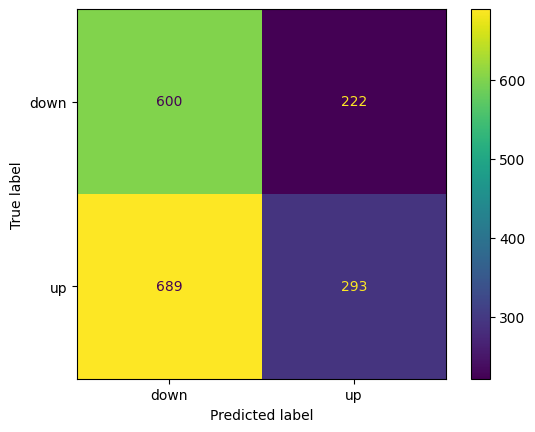


LinearSVC
              precision    recall  f1-score   support

        down      0.505     0.063     0.112       822
          up      0.547     0.948     0.694       982

    accuracy                          0.545      1804
   macro avg      0.526     0.506     0.403      1804
weighted avg      0.528     0.545     0.429      1804



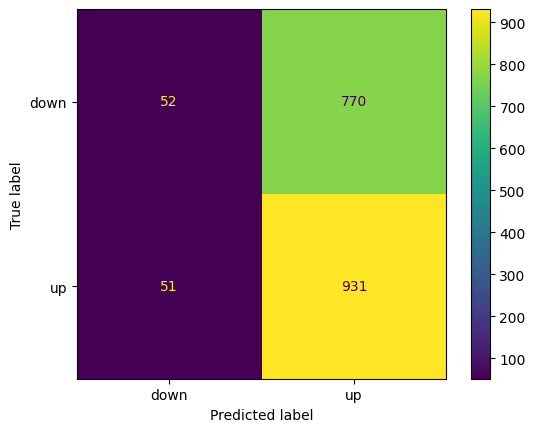


LinearDiscriminantAnalysis
              precision    recall  f1-score   support

        down      0.505     0.063     0.112       822
          up      0.547     0.948     0.694       982

    accuracy                          0.545      1804
   macro avg      0.526     0.506     0.403      1804
weighted avg      0.528     0.545     0.429      1804



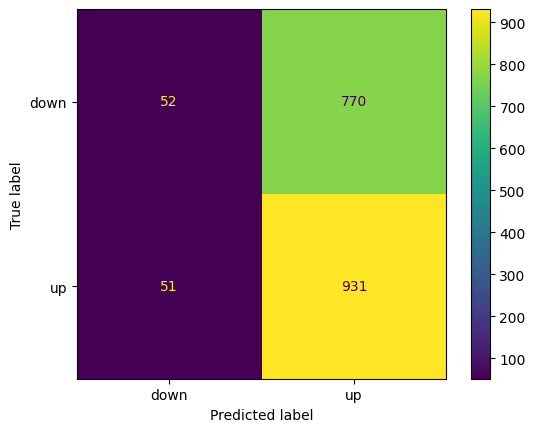


RidgeClassifierCV
              precision    recall  f1-score   support

        down      0.505     0.063     0.112       822
          up      0.547     0.948     0.694       982

    accuracy                          0.545      1804
   macro avg      0.526     0.506     0.403      1804
weighted avg      0.528     0.545     0.429      1804



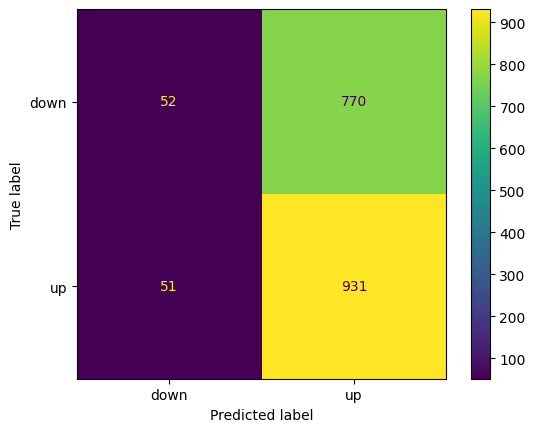


CalibratedClassifierCV
              precision    recall  f1-score   support

        down      0.505     0.063     0.112       822
          up      0.547     0.948     0.694       982

    accuracy                          0.545      1804
   macro avg      0.526     0.506     0.403      1804
weighted avg      0.528     0.545     0.429      1804



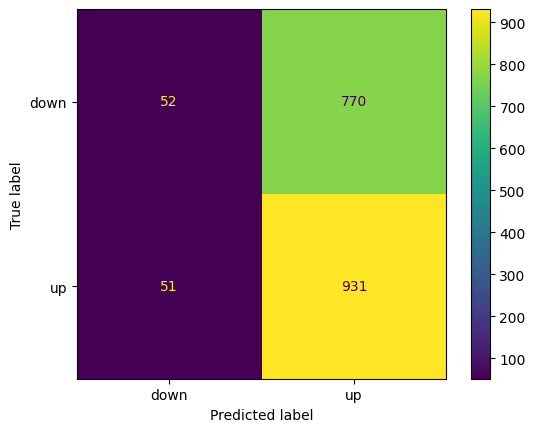


RidgeClassifier
              precision    recall  f1-score   support

        down      0.505     0.063     0.112       822
          up      0.547     0.948     0.694       982

    accuracy                          0.545      1804
   macro avg      0.526     0.506     0.403      1804
weighted avg      0.528     0.545     0.429      1804



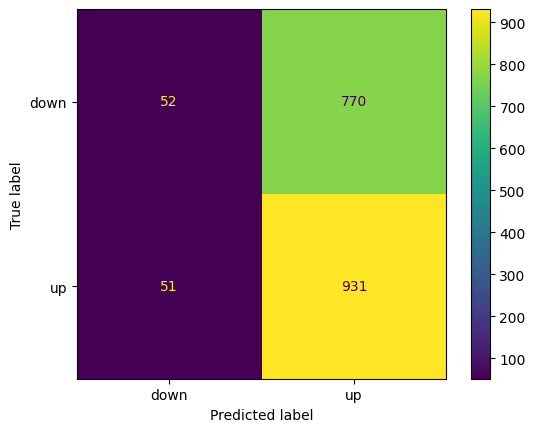


LogisticRegression
              precision    recall  f1-score   support

        down      0.505     0.063     0.112       822
          up      0.547     0.948     0.694       982

    accuracy                          0.545      1804
   macro avg      0.526     0.506     0.403      1804
weighted avg      0.528     0.545     0.429      1804



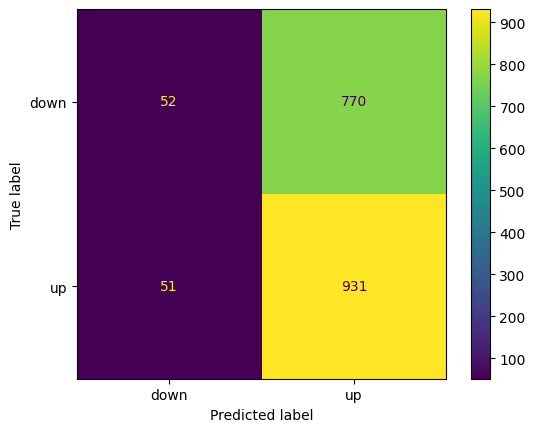


RadiusNeighborsClassifier
              precision    recall  f1-score   support

        down      0.800     0.005     0.010       822
          up      0.545     0.999     0.706       982

    accuracy                          0.546      1804
   macro avg      0.673     0.502     0.358      1804
weighted avg      0.661     0.546     0.388      1804



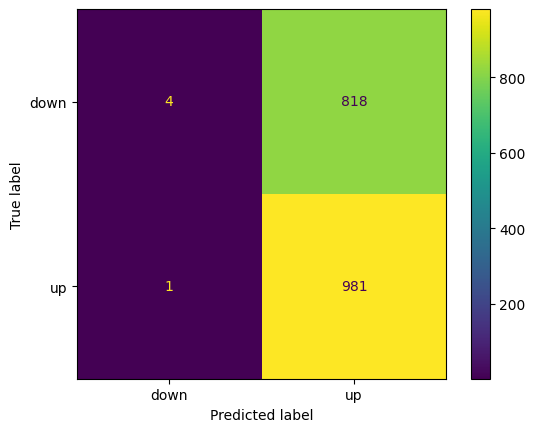


AdaBoostClassifier
              precision    recall  f1-score   support

        down      0.462     0.036     0.068       822
          up      0.545     0.964     0.696       982

    accuracy                          0.542      1804
   macro avg      0.503     0.500     0.382      1804
weighted avg      0.507     0.542     0.410      1804



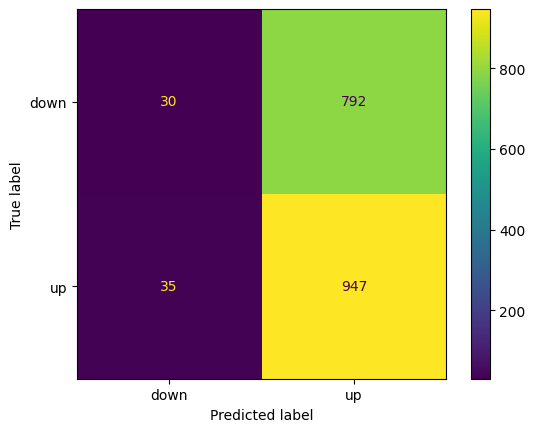


NearestCentroid
              precision    recall  f1-score   support

        down      0.456     0.383     0.416       822
          up      0.544     0.617     0.579       982

    accuracy                          0.511      1804
   macro avg      0.500     0.500     0.497      1804
weighted avg      0.504     0.511     0.505      1804



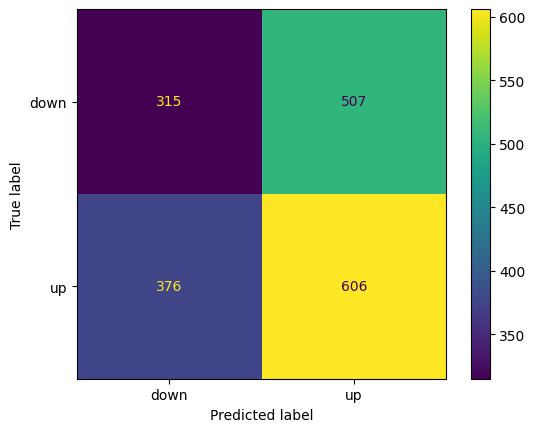


GaussianProcessClassifier
              precision    recall  f1-score   support

        down      0.000     0.000     0.000       822
          up      0.544     1.000     0.705       982

    accuracy                          0.544      1804
   macro avg      0.272     0.500     0.352      1804
weighted avg      0.296     0.544     0.384      1804



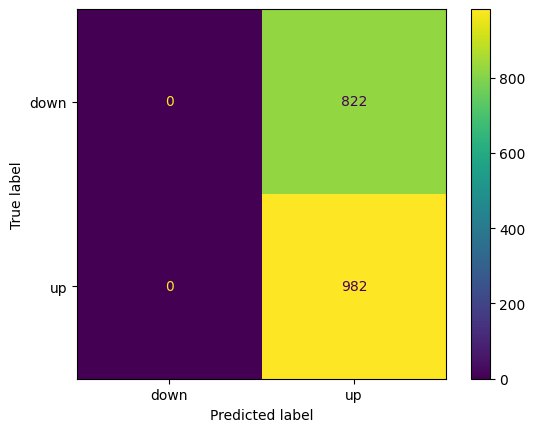


SVC
              precision    recall  f1-score   support

        down      0.000     0.000     0.000       822
          up      0.544     1.000     0.705       982

    accuracy                          0.544      1804
   macro avg      0.272     0.500     0.352      1804
weighted avg      0.296     0.544     0.384      1804



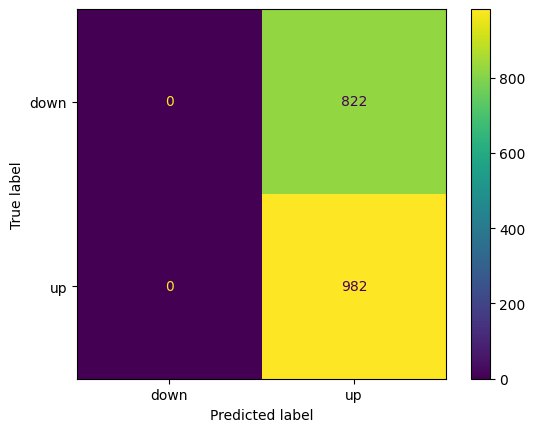


SGDClassifier
              precision    recall  f1-score   support

        down      0.000     0.000     0.000       822
          up      0.544     1.000     0.705       982

    accuracy                          0.544      1804
   macro avg      0.272     0.500     0.352      1804
weighted avg      0.296     0.544     0.384      1804



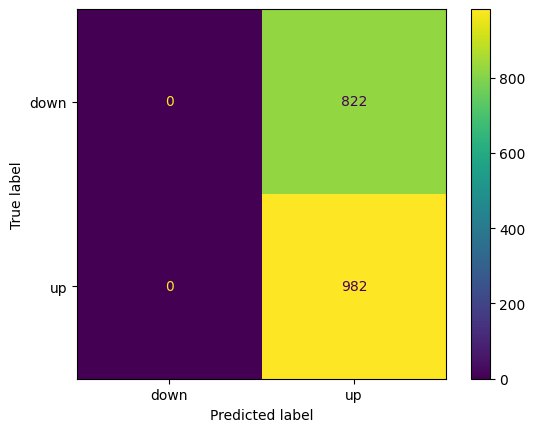


GaussianNB
              precision    recall  f1-score   support

        down      0.000     0.000     0.000       822
          up      0.544     1.000     0.705       982

    accuracy                          0.544      1804
   macro avg      0.272     0.500     0.352      1804
weighted avg      0.296     0.544     0.384      1804



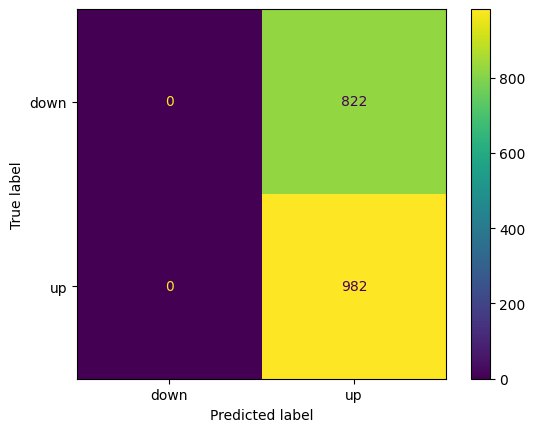


BernoulliNB
              precision    recall  f1-score   support

        down      0.000     0.000     0.000       822
          up      0.544     1.000     0.705       982

    accuracy                          0.544      1804
   macro avg      0.272     0.500     0.352      1804
weighted avg      0.296     0.544     0.384      1804



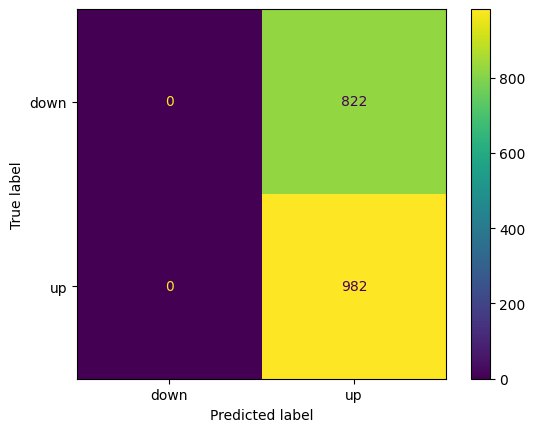


DummyClassifier
              precision    recall  f1-score   support

        down      0.000     0.000     0.000       822
          up      0.544     1.000     0.705       982

    accuracy                          0.544      1804
   macro avg      0.272     0.500     0.352      1804
weighted avg      0.296     0.544     0.384      1804



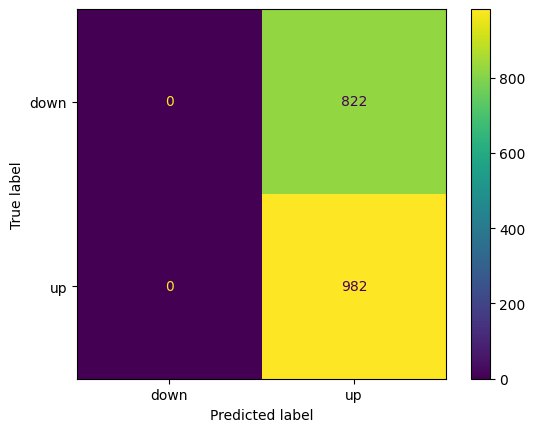


LogisticRegressionCV
              precision    recall  f1-score   support

        down      0.000     0.000     0.000       822
          up      0.544     1.000     0.705       982

    accuracy                          0.544      1804
   macro avg      0.272     0.500     0.352      1804
weighted avg      0.296     0.544     0.384      1804



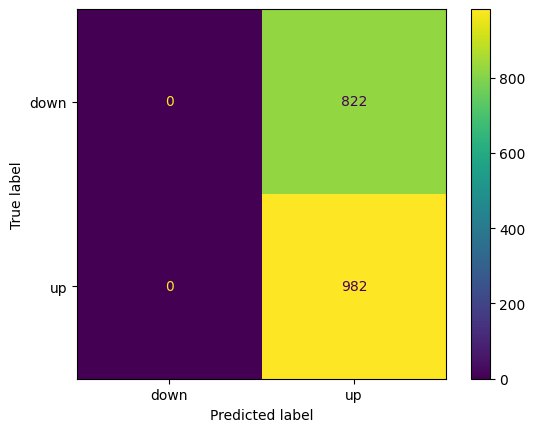


MLPClassifier
              precision    recall  f1-score   support

        down      0.000     0.000     0.000       822
          up      0.544     1.000     0.705       982

    accuracy                          0.544      1804
   macro avg      0.272     0.500     0.352      1804
weighted avg      0.296     0.544     0.384      1804



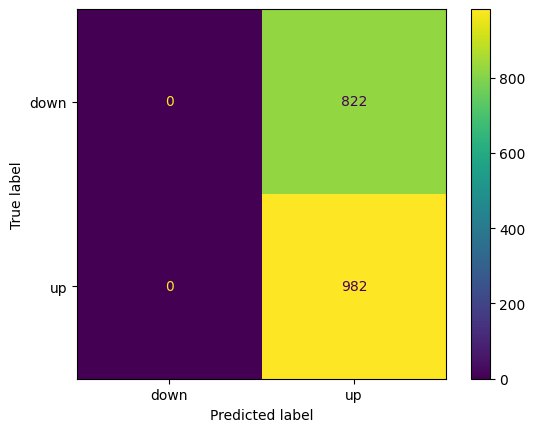


QuadraticDiscriminantAnalysis
              precision    recall  f1-score   support

        down      0.000     0.000     0.000       822
          up      0.544     1.000     0.705       982

    accuracy                          0.544      1804
   macro avg      0.272     0.500     0.352      1804
weighted avg      0.296     0.544     0.384      1804



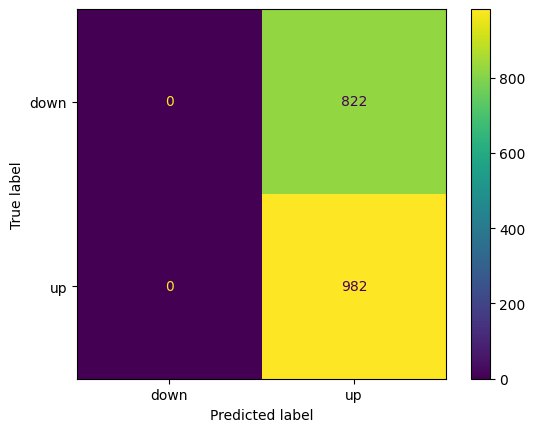


PassiveAggressiveClassifier
              precision    recall  f1-score   support

        down      0.000     0.000     0.000       822
          up      0.544     1.000     0.705       982

    accuracy                          0.544      1804
   macro avg      0.272     0.500     0.352      1804
weighted avg      0.296     0.544     0.384      1804



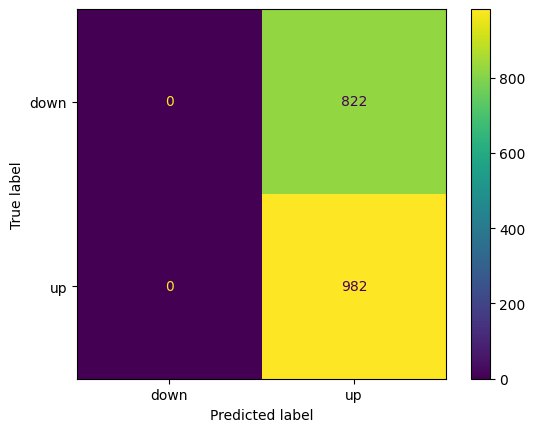


LabelPropagation
              precision    recall  f1-score   support

        down      0.429     0.015     0.028       822
          up      0.544     0.984     0.701       982

    accuracy                          0.542      1804
   macro avg      0.486     0.499     0.364      1804
weighted avg      0.491     0.542     0.394      1804



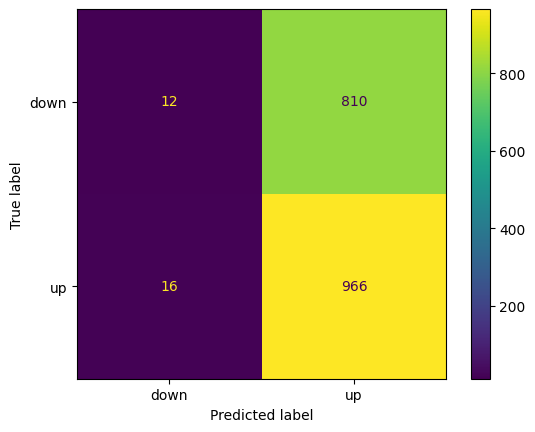


LabelSpreading
              precision    recall  f1-score   support

        down      0.429     0.015     0.028       822
          up      0.544     0.984     0.701       982

    accuracy                          0.542      1804
   macro avg      0.486     0.499     0.364      1804
weighted avg      0.491     0.542     0.394      1804



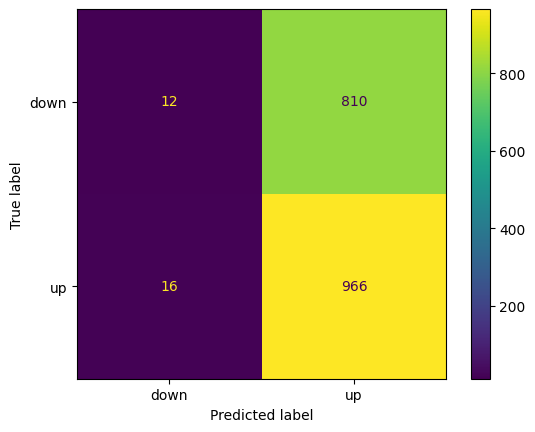


Perceptron
              precision    recall  f1-score   support

        down      0.433     0.123     0.191       822
          up      0.541     0.866     0.666       982

    accuracy                          0.527      1804
   macro avg      0.487     0.494     0.429      1804
weighted avg      0.492     0.527     0.450      1804



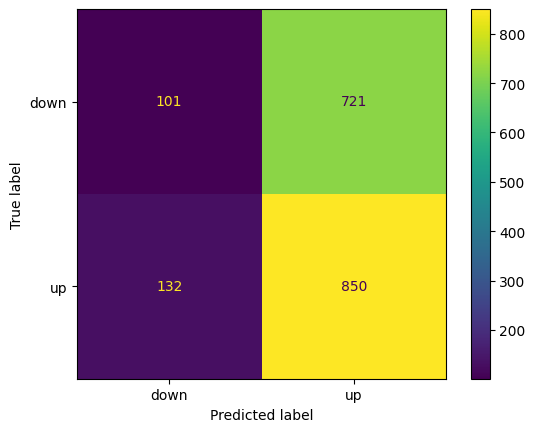


LGBMClassifier
              precision    recall  f1-score   support

        down      0.431     0.118     0.185       822
          up      0.541     0.870     0.667       982

    accuracy                          0.527      1804
   macro avg      0.486     0.494     0.426      1804
weighted avg      0.491     0.527     0.447      1804



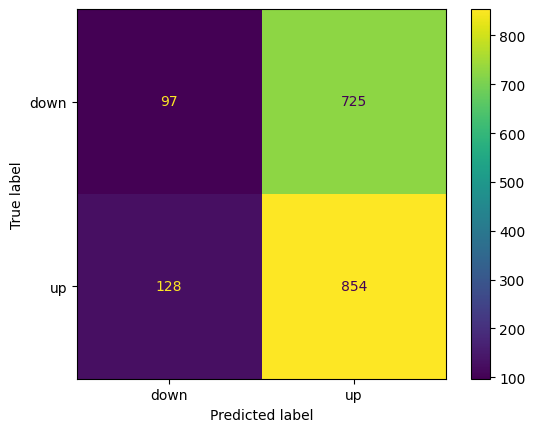


GradientBoostingClassifier
              precision    recall  f1-score   support

        down      0.420     0.096     0.156       822
          up      0.540     0.889     0.672       982

    accuracy                          0.528      1804
   macro avg      0.480     0.493     0.414      1804
weighted avg      0.486     0.528     0.437      1804



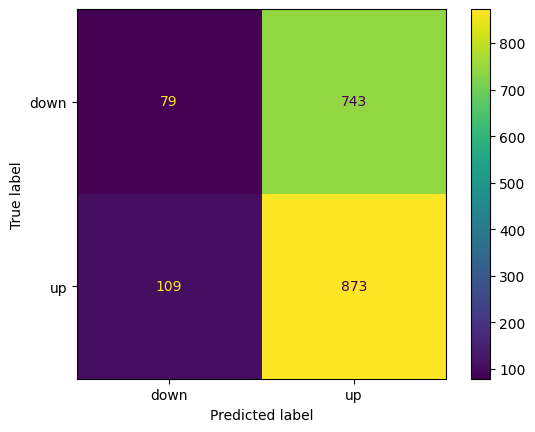


XGBClassifier
              precision    recall  f1-score   support

        down      0.413     0.101     0.162       822
          up      0.539     0.880     0.668       982

    accuracy                          0.525      1804
   macro avg      0.476     0.490     0.415      1804
weighted avg      0.482     0.525     0.438      1804



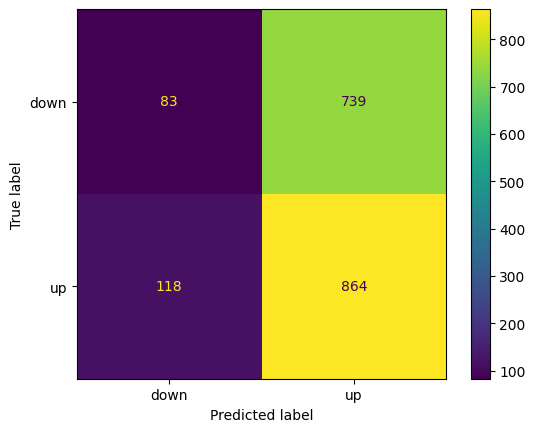


HistGradientBoostingClassifier
              precision    recall  f1-score   support

        down      0.423     0.137     0.208       822
          up      0.539     0.843     0.657       982

    accuracy                          0.522      1804
   macro avg      0.481     0.490     0.432      1804
weighted avg      0.486     0.522     0.452      1804



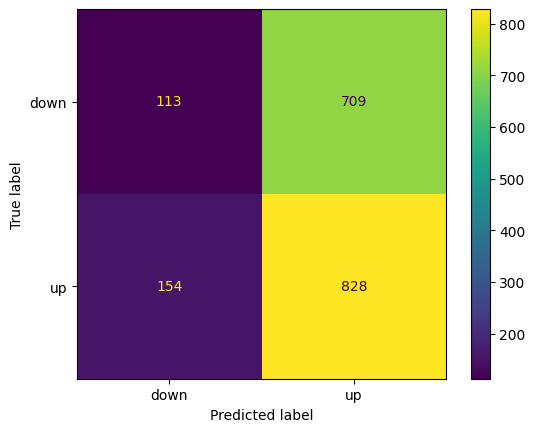


BaggingClassifier
              precision    recall  f1-score   support

        down      0.410     0.114     0.179       822
          up      0.538     0.863     0.662       982

    accuracy                          0.522      1804
   macro avg      0.474     0.488     0.421      1804
weighted avg      0.480     0.522     0.442      1804



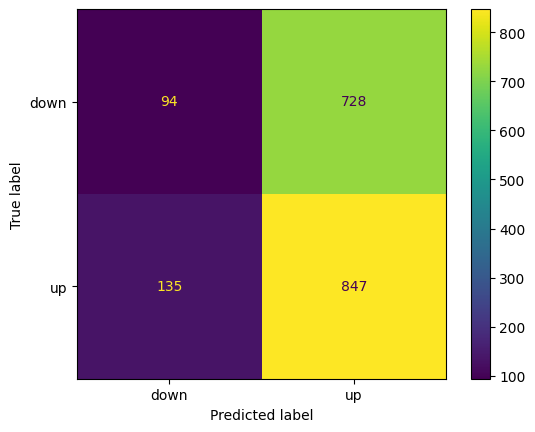


RandomForestClassifier
              precision    recall  f1-score   support

        down      0.420     0.151     0.222       822
          up      0.537     0.826     0.651       982

    accuracy                          0.518      1804
   macro avg      0.479     0.488     0.437      1804
weighted avg      0.484     0.518     0.456      1804



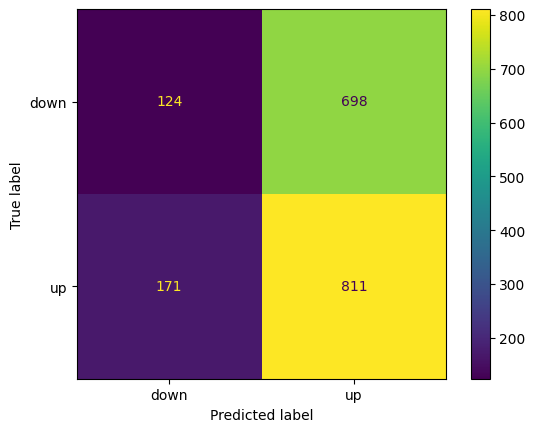


KNeighborsClassifier
              precision    recall  f1-score   support

        down      0.435     0.388     0.410       822
          up      0.530     0.577     0.553       982

    accuracy                          0.491      1804
   macro avg      0.482     0.483     0.481      1804
weighted avg      0.486     0.491     0.488      1804



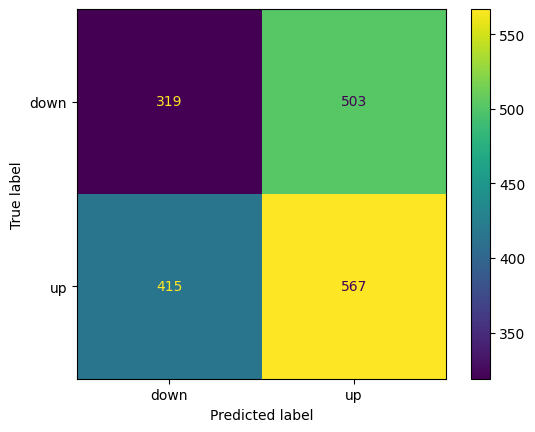


ExtraTreesClassifier
              precision    recall  f1-score   support

        down      0.402     0.152     0.221       822
          up      0.533     0.811     0.643       982

    accuracy                          0.511      1804
   macro avg      0.468     0.481     0.432      1804
weighted avg      0.473     0.511     0.451      1804



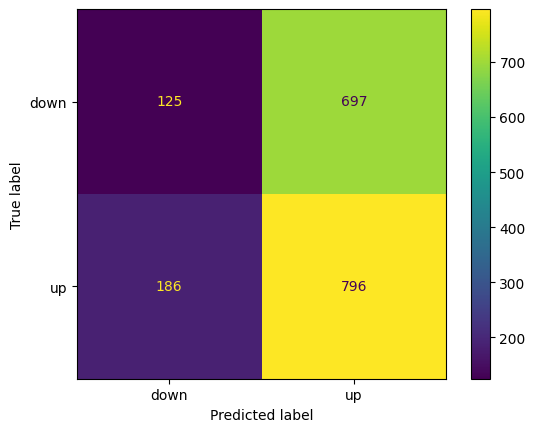


DecisionTreeClassifier
              precision    recall  f1-score   support

        down      0.402     0.152     0.221       822
          up      0.533     0.811     0.643       982

    accuracy                          0.511      1804
   macro avg      0.468     0.481     0.432      1804
weighted avg      0.473     0.511     0.451      1804



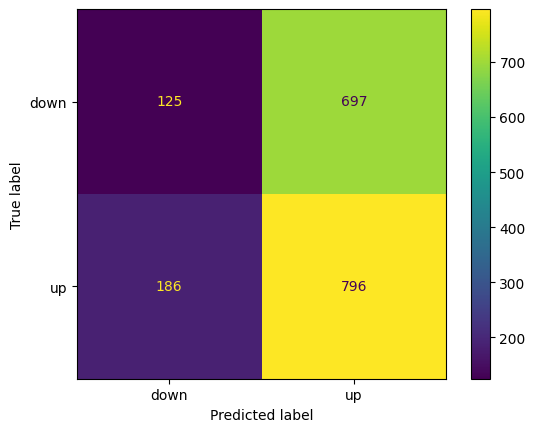


ExtraTreeClassifier
              precision    recall  f1-score   support

        down      0.402     0.152     0.221       822
          up      0.533     0.811     0.643       982

    accuracy                          0.511      1804
   macro avg      0.468     0.481     0.432      1804
weighted avg      0.473     0.511     0.451      1804



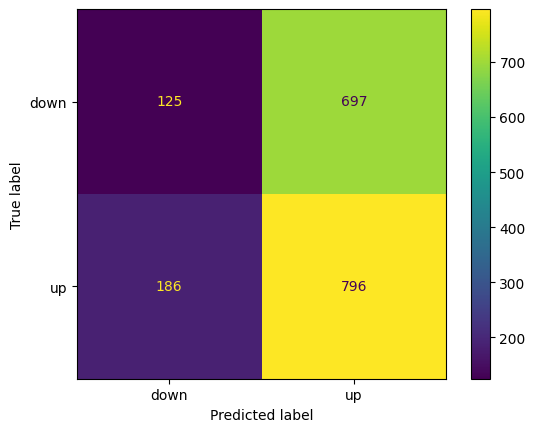

In [25]:
for i in Result.index:
    print(i)

    cm = confusion_matrix(y_test, predictions[i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot();

    print(classification_report(y_test, predictions[i], target_names=target_names, digits=3))

    temp = [recall_score(y_test, predictions[i], average=None)[0],
            recall_score(y_test, predictions[i], average=None)[1],
            recall_score(y_test, predictions[i], average=None).sum(),
            accuracy_score(y_test, predictions[i])]
    Result.loc[i] = temp

    plt.show()
    print()


In [26]:
Result.style.highlight_max()

,recall_0,recall_1,recall_sum,acc
Model,,,,
NuSVC,0.729927,0.298371,1.028298,0.495011
LinearSVC,0.063260,0.948065,1.011326,0.544900
LinearDiscriminantAnalysis,0.063260,0.948065,1.011326,0.544900
RidgeClassifierCV,0.063260,0.948065,1.011326,0.544900
CalibratedClassifierCV,0.063260,0.948065,1.011326,0.544900
RidgeClassifier,0.063260,0.948065,1.011326,0.544900
LogisticRegression,0.063260,0.948065,1.011326,0.544900
RadiusNeighborsClassifier,0.004866,0.998982,1.003848,0.546009
AdaBoostClassifier,0.036496,0.964358,1.000855,0.541574
